In [68]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

In [69]:
prices_df = pd.read_csv("IndustryPrices.csv", index_col=0) #LOAD CSV FILE IN
prices_df.sort_index(inplace=True) #SORT BASED ON DATES
prices_df = prices_df.apply(pd.to_numeric, errors='coerce') #CONVERT ANY STRINGS TO NUMERIC



In [70]:
# --------------------------------------------------------------------
# Caclulate Daily Returns (from the previous row: (P_t / P_t-1) - 1.)
# --------------------------------------------------------------------
daily_returns = prices_df.pct_change().dropna() #DROP FIRST ROW and CALCULATE DAILY RETURNS (FOR 252 TRADING DAYS PER YEAR)
print(daily_returns.head())

                AAPL      MSFT      AMZN     GOOGL      META      ORCL  \
Date                                                                     
2015-04-07 -0.010522 -0.000482 -0.006975  0.001673 -0.001456  0.000000   
2015-04-08 -0.003254 -0.002649  0.018135  0.007305 -0.000486  0.003492   
2015-04-09  0.007643  0.001448  0.006139 -0.001494 -0.001337  0.002088   
2015-04-10  0.004267  0.005786 -0.002321  0.000949 -0.001582  0.007176   
2015-04-13 -0.001967  0.000959 -0.000758  0.000182  0.011824 -0.009883   

                 CRM      ADBE       IBM      INTC  ...       SRE        ED  \
Date                                                ...                       
2015-04-07  0.003827 -0.007609  0.000185  0.007087  ... -0.005974 -0.015597   
2015-04-08  0.000147 -0.002776 -0.001358  0.001599  ... -0.010928  0.000165   
2015-04-09 -0.006891  0.011797  0.003027 -0.002236  ... -0.006537 -0.005610   
2015-04-10 -0.001476  0.002620  0.003203  0.022087  ... -0.000464  0.009957   
2015-04

<ipython-input-70-18319e2a52e0>:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = prices_df.pct_change().dropna() #DROP FIRST ROW and CALCULATE DAILY RETURNS (FOR 252 TRADING DAYS PER YEAR)


In [64]:
# -------------------------------------------
# Calculate Average Daily Return for Each Stock. (# μ_i = (1 / N) * sum_{t=1}^{N} r_{i,t})
# exp_daily_returns
# -------------------------------------------
exp_daily_returns = daily_returns.mean()
print(exp_daily_returns)

AAPL     0.000945
MSFT     0.001076
AMZN     0.001106
GOOGL    0.000846
META     0.001030
           ...   
FE       0.000352
CMS      0.000504
DTE      0.000501
CNP      0.000508
ES       0.000319
Length: 153, dtype: float64


In [63]:
# -------------------------------------------
# Annualize the Daily Return:
# annualized_returns
#
# Using the formula for compound growth over 252 trading days:
# Annualized Return = (1 + μ_i)^(252) - 1
# -------------------------------------------
annualized_returns = (1 + exp_daily_returns) ** (252) - 1
print(annualized_returns)


AAPL     0.268636
MSFT     0.311418
AMZN     0.321114
GOOGL    0.237566
META     0.296036
           ...   
FE       0.092840
CMS      0.135429
DTE      0.134478
CNP      0.136539
ES       0.083740
Length: 153, dtype: float64


In [ ]:
# -------------------------------------------
# Calculate daily log returns
# geo_annual_returns
# -------------------------------------------

log_returns = np.log(prices_df / prices_df.shift(1)).dropna()

# 2. Compute the average (mean) of the daily log returns
avg_log_returns = log_returns.mean()  # average across all days (for each ticker)

# 3. Convert to a geometric mean return and annualize
#    For ~252 trading days/year, we multiply by 252 and exponentiate
geo_annual_returns = np.exp(avg_log_returns * 252) - 1

# (Optional) Multiply by 100 to show percentages
geo_annual_returns_percent = geo_annual_returns * 100
print("\nGeometric Mean Annualized Returns (%):")
print(geo_annual_returns_percent)

In [66]:
# Create a DataFrame to compare both returns side-by-side (multiply by 100 to express as percentages)
returns_comparison = pd.DataFrame({
    "Avg Daily Return (%)": exp_daily_returns * 100,
    "Annualized Return (%)": annualized_returns * 100,
    "Annualized Log Return (%)": geo_annual_returns_percent
})

# Print the complete comparison DataFrame.
print(returns_comparison.to_string())

       Avg Daily Return (%)  Annualized Return (%)  Annualized Log Return (%)
AAPL               0.094466              26.863628                  21.777168
MSFT               0.107641              31.141825                  26.451514
AMZN               0.110567              32.111421                  25.256487
GOOGL              0.084618              23.756639                  18.773508
META               0.102954              29.603564                  20.590158
ORCL               0.068331              18.783923                  14.058967
CRM                0.076858              21.362110                  14.245017
ADBE               0.084978              23.868760                  17.062916
IBM                0.046778              12.507936                   9.252039
INTC               0.024749               6.434603                  -0.669633
NVDA               0.257959              91.404573                  69.612561
CSCO               0.054360              14.677129              

In [ ]:
# Calculate the covariance matrix from daily returns
# Each diagonal entry represents the variance of a stock’s returns—how spread out its returns are over time
# Off-Diagonal Elements: (These indicate how two stocks move together. A positive covariance means the stocks tend to move in the same direction; a negative covariance means they move inversely.)
cov_matrix = log_returns.cov()

# Print the entire covariance matrix without truncation
print(cov_matrix.to_string())


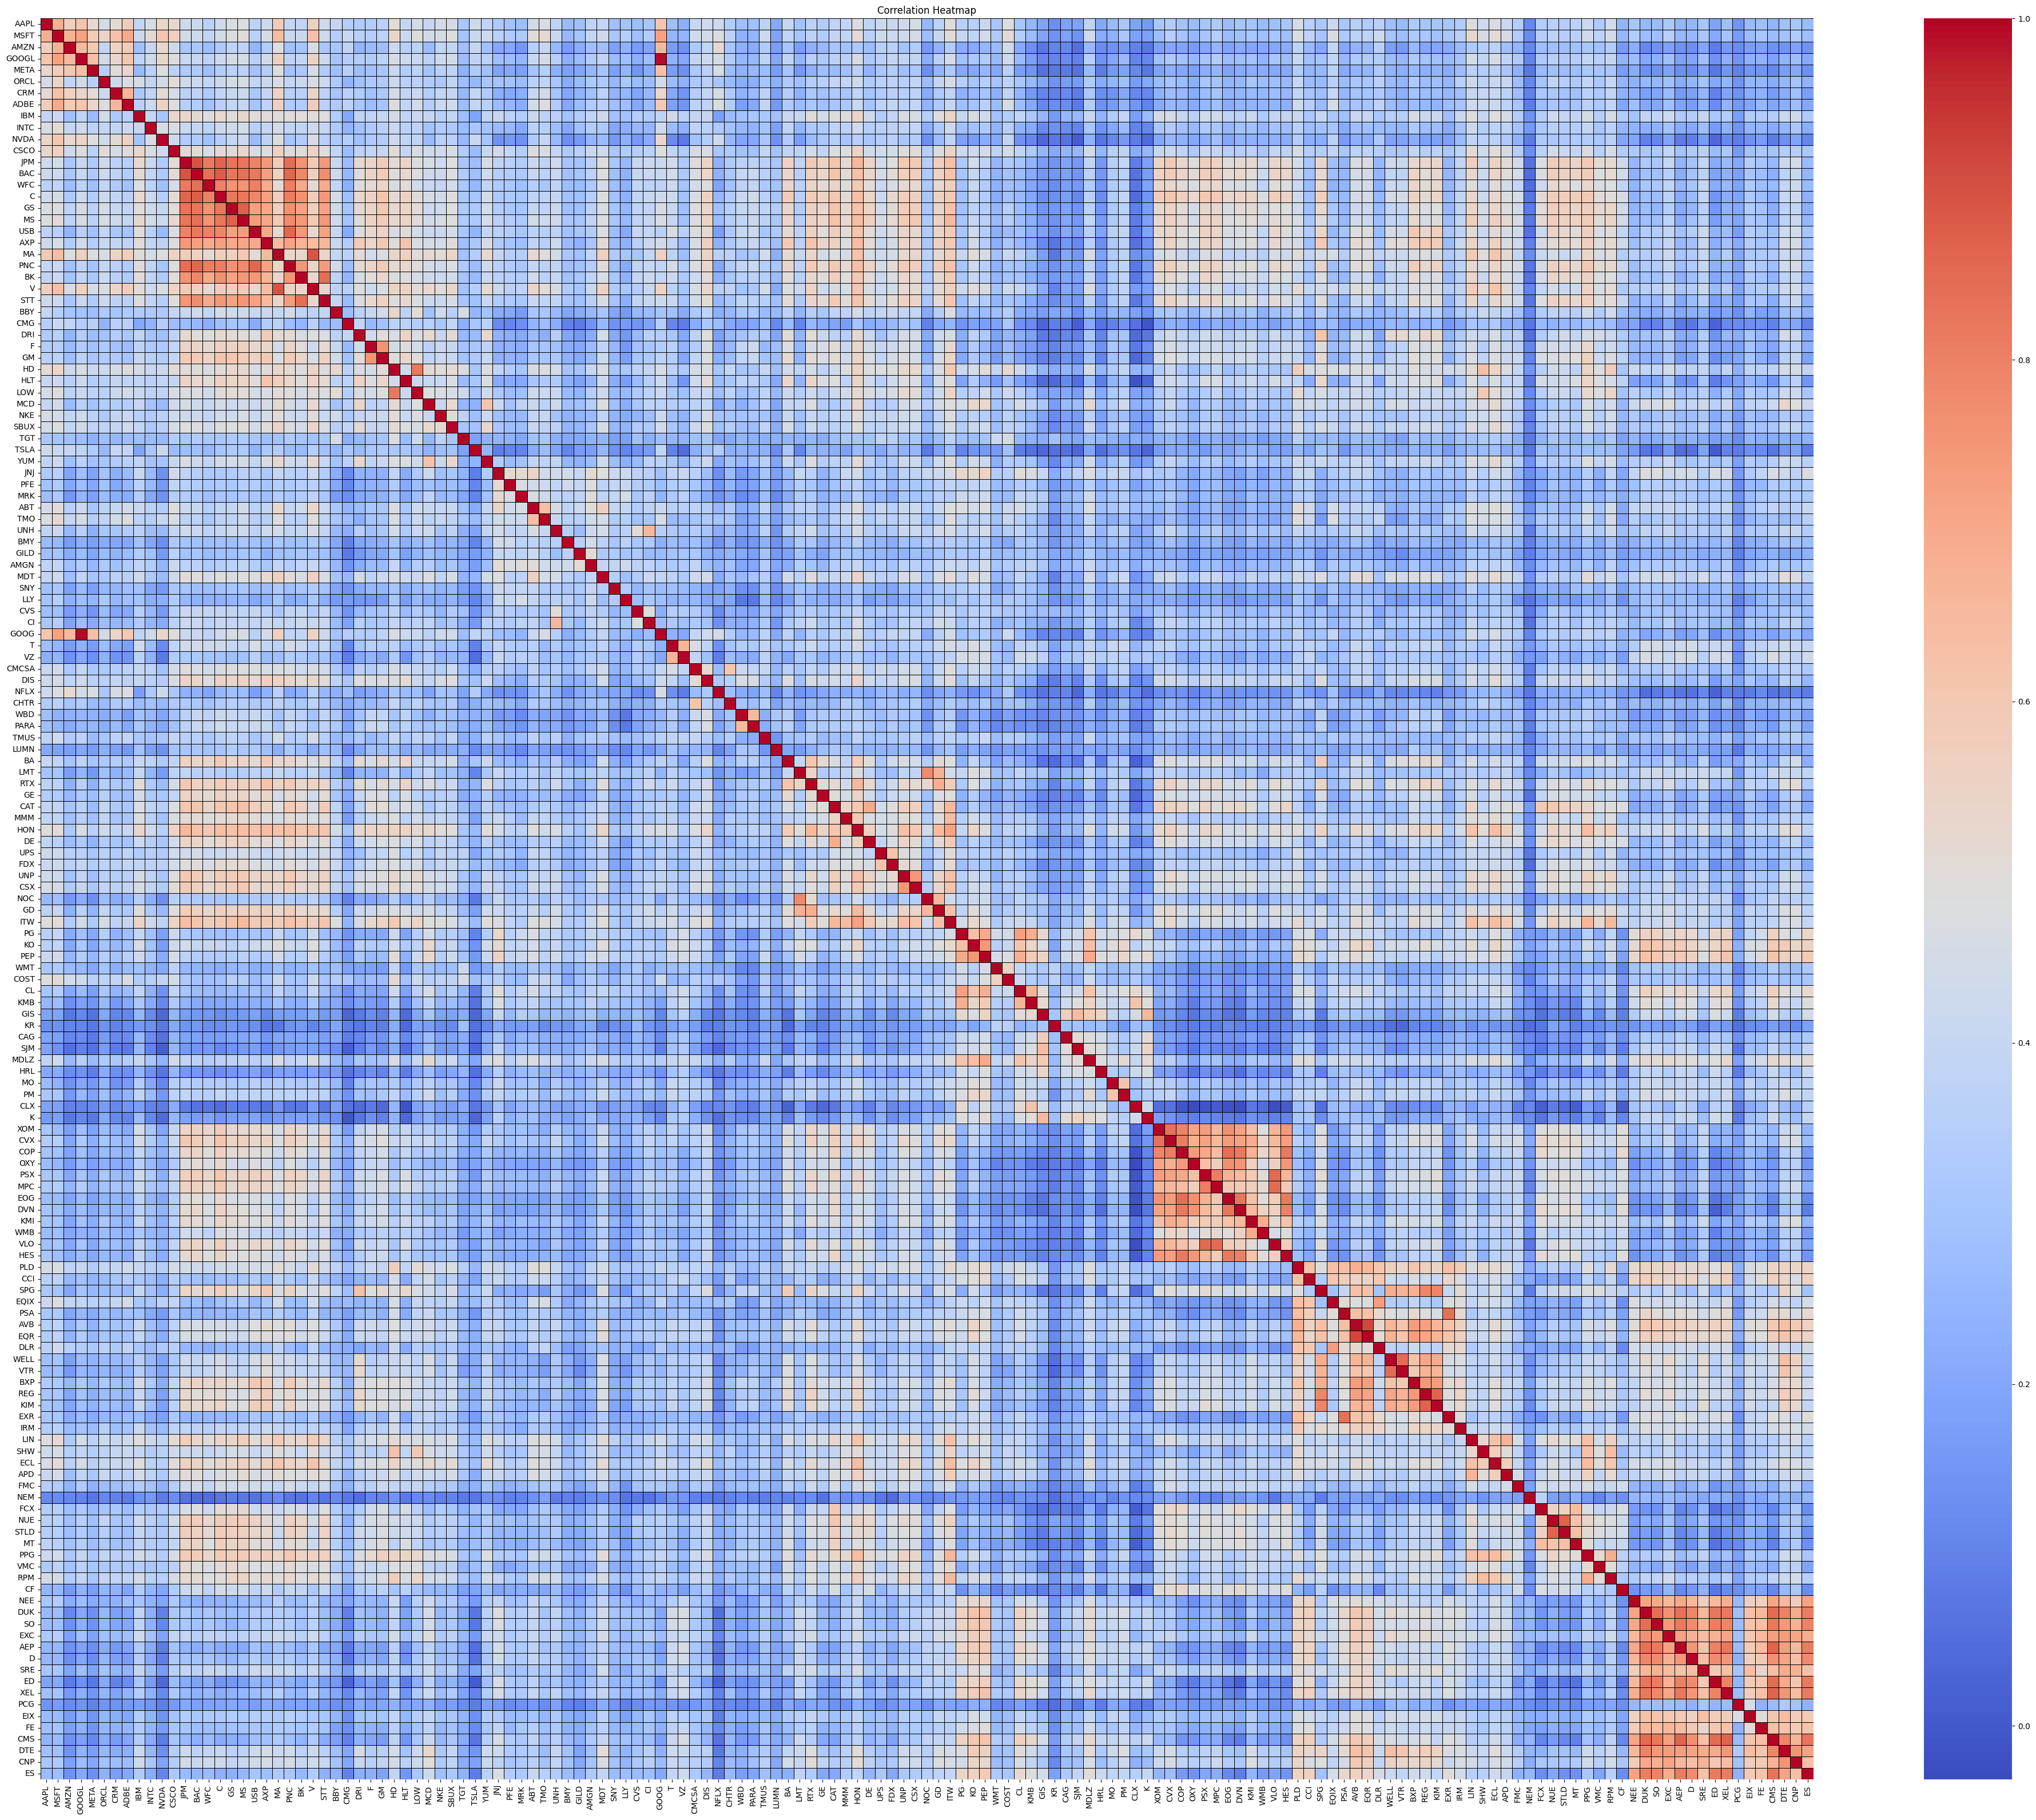

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt



# Calculate the Correlation Matrix from daily returns of Cov_matrix
cov_matrix = log_returns.corr()


# Blocks of dark red (close to +1) often indicate a set of stocks that move in sync—perhaps all from the same sector or influenced by the same macro factors.
# Blocks of dark blue (close to –1) would indicate a set of stocks moving inversely.

plt.figure(figsize=(50, 40))
sns.heatmap(cov_matrix,
            cmap='coolwarm',
            annot=False,
            linewidths=0.5,        # thickness of the lines
            linecolor='black')     # color of the lines
plt.title("Correlation Heatmap")
plt.show()
